# Import Libraries

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load and Display quote.png

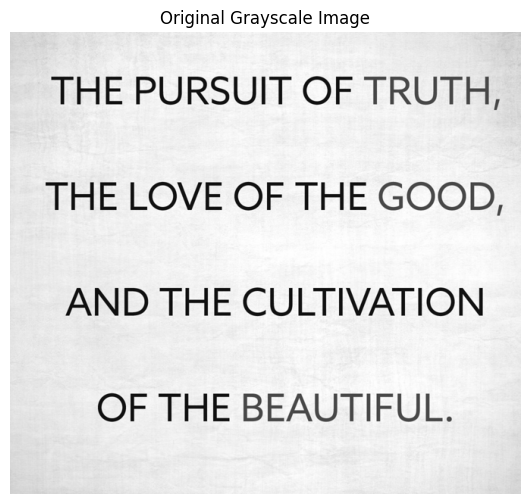

In [42]:
# Load image
img = cv2.imread("quote.png")

# Convert BGR to RGB for displaying with matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 6))

plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")

plt.show()

# Binarize quote.png

In [ ]:
# Otsu's binarization
threshold_value, binary = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print("Otsu Threshold =", threshold_value)

plt.figure(figsize=(10, 6))

plt.imshow(binary, cmap="gray")
plt.title(f"Binarized Image (Otsu Threshold = {threshold_value:.0f})")
plt.axis("off")

plt.show()

Otsu Threshold = 142.0


# Manual 8-Connected Component Analysis

In [ ]:
# Make a copy of the binary image
binary_copy = binary.copy()

# Image dimensions
height, width = binary_copy.shape

# Label image
# 0 means unvisited/background
labels = np.zeros((height, width), dtype=np.int32)

# Start component numbering from 1
current_label = 0

# Store area of every component
component_areas = {}

# 8-connected neighbors
neighbors = [
    (-1, -1), (-1, 0), (-1, 1),
    ( 0, -1),          ( 0, 1),
    ( 1, -1), ( 1, 0), ( 1, 1)
]

# Scan every pixel

for i in range(height):
    for j in range(width):

        # We only care about character pixels
        # binary = 255 means foreground
        if binary_copy[i, j] == 255 and labels[i, j] == 0:

            # New connected component
            current_label += 1

            # Stack for DFS
            stack = [(i, j)]

            # Label starting pixel
            labels[i, j] = current_label

            # Count pixels in this component
            area = 0

            # DFS

            while stack:

                x, y = stack.pop()

                area += 1

                # Check all 8 neighbors
                for dx, dy in neighbors:

                    nx = x + dx
                    ny = y + dy

                    # Check image boundaries
                    if (
                        nx >= 0 and nx < height and
                        ny >= 0 and ny < width
                    ):

                        # Check whether neighbor is:
                        # 1. A character pixel
                        # 2. Not already labeled
                        if (
                            binary_copy[nx, ny] == 255
                            and labels[nx, ny] == 0
                        ):

                            labels[nx, ny] = current_label

                            stack.append((nx, ny))

            # Store component area
            component_areas[current_label] = area


print("Number of connected components:", current_label)

In [ ]:
# Display area of every connected component

print("Connected Component Areas")
print("==============================")

for label in range(1, current_label + 1):

    area = component_areas[label]

    print(
        f"Component {label:2d} : "
        f"{area:4d} pixels"
    )

# Visualize Connected Components

In [ ]:
# Create a color image from the grayscale image
component_visualization = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

# current_label = total number of components
# labels = image containing our manually assigned component labels

for label in range(1, current_label + 1):

    # Find all pixels belonging to this component
    positions = np.argwhere(labels == label)

    # Skip if component does not exist
    if len(positions) == 0:
        continue

    # Get row and column coordinates
    y_coordinates = positions[:, 0]
    x_coordinates = positions[:, 1]

    # Calculate bounding box manually

    x_min = np.min(x_coordinates)
    x_max = np.max(x_coordinates)

    y_min = np.min(y_coordinates)
    y_max = np.max(y_coordinates)

    width = x_max - x_min + 1
    height = y_max - y_min + 1

    # Calculate centroid manually

    cx = np.mean(x_coordinates)
    cy = np.mean(y_coordinates)

    # Draw bounding box

    cv2.rectangle(
        component_visualization,
        (x_min, y_min),
        (x_max, y_max),
        (255, 0, 0),
        1
    )

    # Put component number near centroid

    cv2.putText(
        component_visualization,
        str(label),
        (int(cx), int(cy)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.4,
        (255, 0, 0),
        1
    )

# Display

plt.figure(figsize=(15, 8))

plt.imshow(component_visualization)

plt.title(
    f"Connected Components with Labels "
    f"(Total Components = {current_label})"
)

plt.axis("off")

plt.show()

# Find Largest Character Component

In [ ]:
# Find Largest Character Component
# Ignore background (label 0)

largest_component = 1
largest_area = component_areas[1]

# Check every connected component
for label in range(2, current_label + 1):

    area = component_areas[label]

    if area > largest_area:
        largest_area = area
        largest_component = label

print("================================")
print("Largest Connected Component")
print("================================")
print("Component Label =", largest_component)
print("Area =", largest_area, "pixels")

# Highlight Largest Component in Red

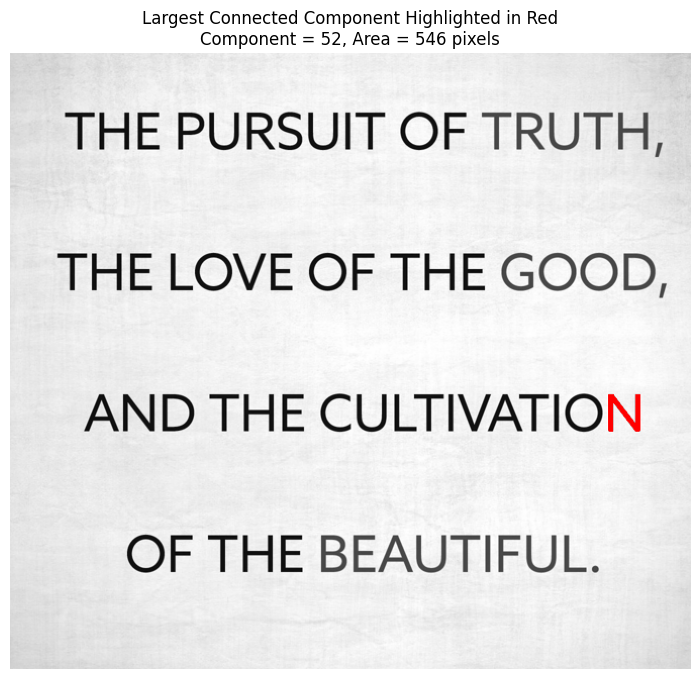

In [ ]:
# Create a copy of the original image
highlighted = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

# Find pixels belonging to the largest component
component_mask = (labels == largest_component)

# Color those pixels red
highlighted[component_mask] = [255, 0, 0]

# Display the result
plt.figure(figsize=(15, 8))

plt.imshow(highlighted)

plt.title(
    f"Largest Connected Component Highlighted in Red\n"
    f"Component = {largest_component}, "
    f"Area = {largest_area} pixels"
)

plt.axis("off")

plt.show()

# Save Largest Component Highlighted in Red

In [ ]:
# Save the modified image
output_path = "quote_largest_component_red.png"

cv2.imwrite(
    output_path,
    cv2.cvtColor(highlighted, cv2.COLOR_RGB2BGR)
)

print("Image saved as:", output_path)

Image saved as: quote_largest_component_red.png
